In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.feature import canny

# load image
image = io.imread('images/test_image_3.jpeg')

if len(image.shape) == 3:
    gray_image = color.rgb2gray(image)
    gray_image = (gray_image * 255).astype(np.uint8)
else:
    gray_image = image

def global_threshold(image, T):
    mask = np.where(image > T, 255, 0).astype(np.uint8)
    return mask

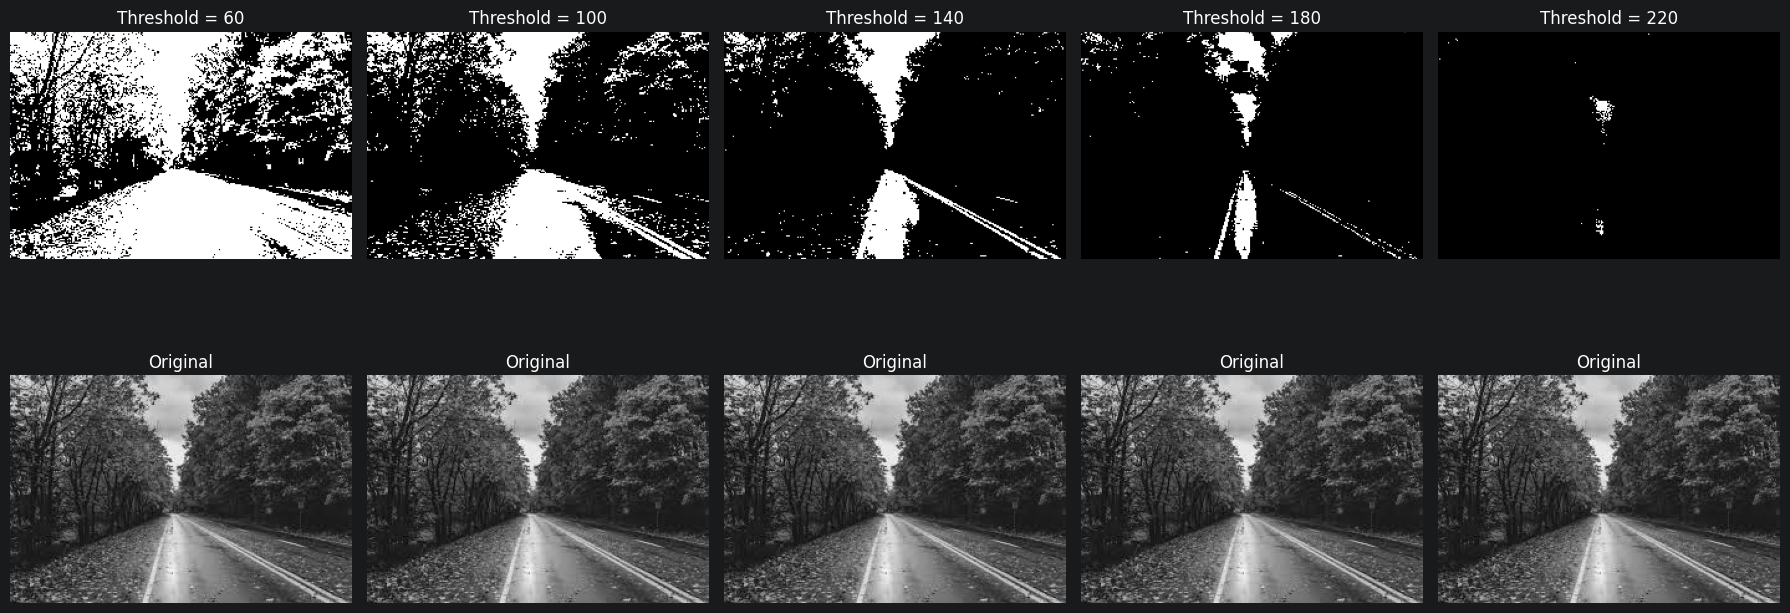

Threshold 60:
- Very low threshold → too much white (over-segmentation).
- White pixels: 27674
- Black pixels: 22651

Threshold 100:
- Object starts separating but still noisy.
- White pixels: 12743
- Black pixels: 37582

Threshold 140:
- Best balance → object and background well separated.
- White pixels: 6541
- Black pixels: 43784

Threshold 180:
- Losing object details.
- White pixels: 3010
- Black pixels: 47315

Threshold 220:
- Only brightest pixels remain → object lost.
- White pixels: 195
- Black pixels: 50130



In [29]:
# Task 1: Try Different Threshold Values
thresholds = [60, 100, 140, 180, 220]

fig, axes = plt.subplots(2, len(thresholds), figsize=(18, 8))

for i, T in enumerate(thresholds):
    mask = global_threshold(gray_image, T)

    axes[0, i].imshow(mask, cmap="gray")
    axes[0, i].set_title(f"Threshold = {T}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gray_image, cmap="gray")
    axes[1, i].set_title("Original")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

for T in thresholds:
    mask = global_threshold(gray_image, T)

    white_pixels = np.sum(mask == 255)
    black_pixels = np.sum(mask == 0)

    print(f"Threshold {T}:")

    if T == 60:
        print("- Very low threshold → too much white (over-segmentation).")

    elif T == 100:
        print("- Object starts separating but still noisy.")

    elif T == 140:
        print("- Best balance → object and background well separated.")

    elif T == 180:
        print("- Losing object details.")

    elif T == 220:
        print("- Only brightest pixels remain → object lost.")

    print(f"- White pixels: {white_pixels}")
    print(f"- Black pixels: {black_pixels}")
    print()

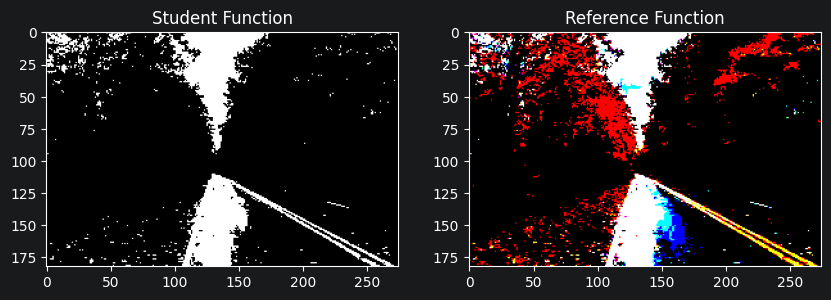

In [32]:
# Task 2: Build Your Own Segmentation Function
def my_threshold(image, T):
    if len(image.shape) == 3:
        image = color.rgb2gray(image)
        image = (image * 255).astype(np.uint8)

    mask = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            if image[i, j] >= T:
                mask[i, j] = 1
            else:
                mask[i, j] = 0

    return mask

student_mask = my_threshold(image, 140)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(student_mask, cmap="gray")
plt.title("Student Function")

plt.subplot(1,2,2)
plt.imshow(global_threshold(gray_image, 140), cmap="gray")
plt.title("Reference Function")
plt.show()


In [ ]:
# Task 3: Noise Challenge
# 1. What happens to the mask?
# The mask becomes noisy and less accurate.
# Random pixels appear as object or background incorrectly due to noise.
#
# 2. Does the same threshold still work?
# No, the same threshold does not work well.
# Noise changes pixel values, making the segmentation less reliable.
#
# 3. What could you do to improve the result?
# To improve the result, we can:
# Apply smoothing filters (Gaussian or Median)
# Reduce noise before thresholding
# Adjust the threshold value
# Use adaptive thresholding

Automatic threshold: 102


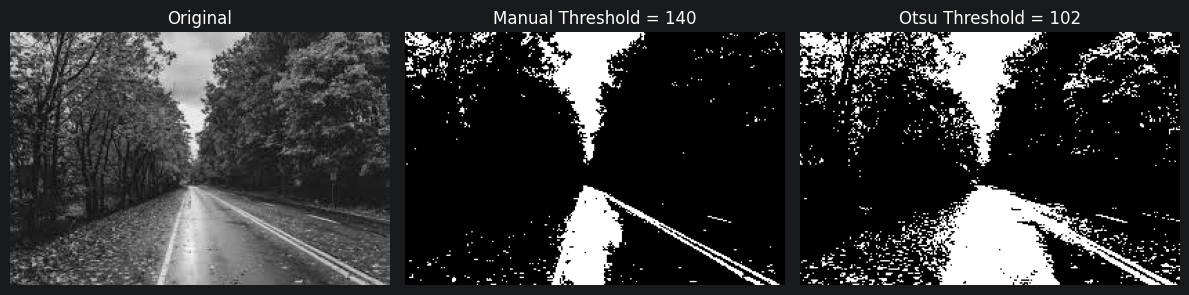

In [38]:
# Challenge 1: Automatic Threshold Selection
if len(image.shape) == 3:
    gray_image = color.rgb2gray(image)
    gray_image = (gray_image * 255).astype(np.uint8)
else:
    gray_image = image

T_otsu = threshold_otsu(gray_image)
print("Automatic threshold:", T_otsu)

mask_otsu = gray_image >= T_otsu

manual_T = 140
manual_mask = gray_image >= manual_T

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_mask, cmap="gray")
plt.title(f"Manual Threshold = {manual_T}")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask_otsu, cmap="gray")
plt.title(f"Otsu Threshold = {T_otsu}")
plt.axis("off")

plt.tight_layout()
plt.show()

# Otsu’s method automatically selects a threshold value based on the image intensity distribution.
# This removes the need to choose the threshold manually.
# The automatic result can be compared with the manual threshold result.
# In this example, Otsu’s threshold may provide better or more balanced segmentation.

In [42]:
# Challenge 2: Count the Number of White Pixels
mask_global = global_threshold(gray_image, 140)

foreground_pixels = np.sum(mask_global == 255)
total_pixels = mask_global.size
percentage = 100 * foreground_pixels / total_pixels

print("Foreground pixels:", foreground_pixels)
print("Percentage selected:", round(percentage, 2), "%")

Foreground pixels: 6541
Percentage selected: 13.0 %


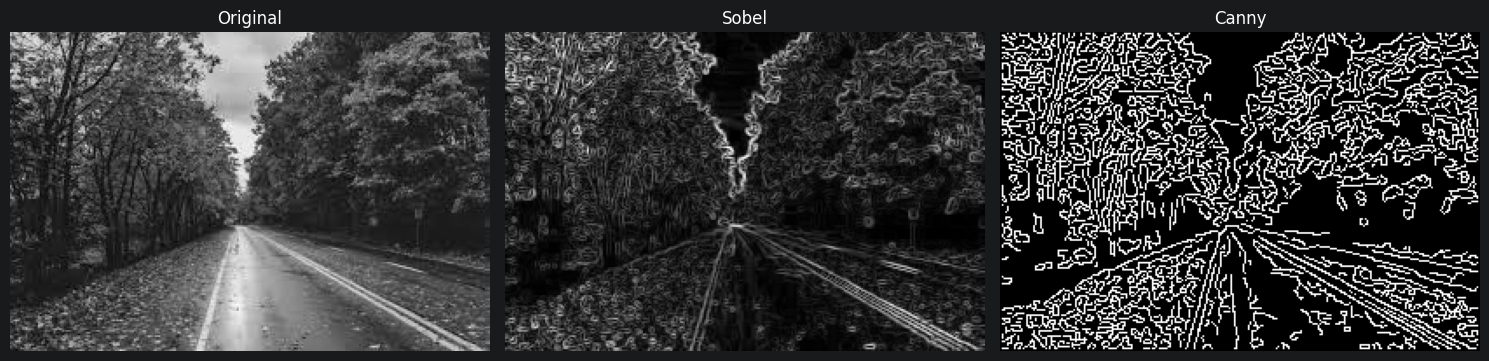

In [44]:
# Challenge 3: Edge Detection Comparison
if len(image.shape) == 3:
    gray_image = color.rgb2gray(image)
else:
    gray_image = image / 255.0 if image.max() > 1 else image

edges_sobel = sobel(gray_image)

edges_canny = canny(gray_image)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(edges_sobel, cmap="gray")
axes[1].set_title("Sobel")

axes[2].imshow(edges_canny, cmap="gray")
axes[2].set_title("Canny")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

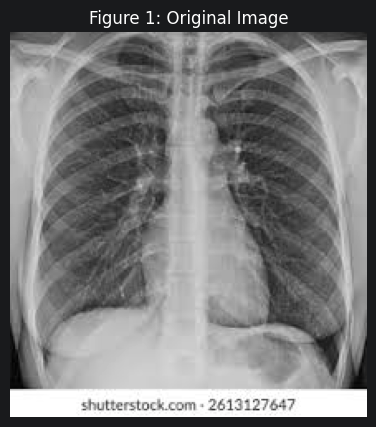

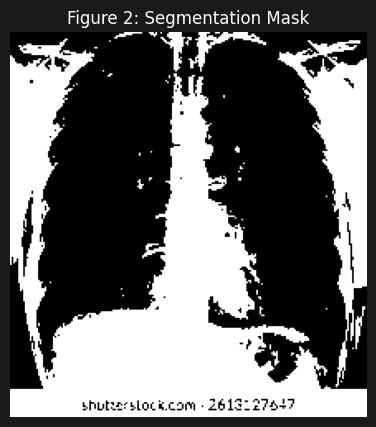

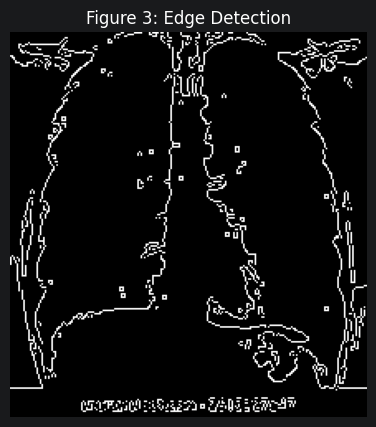

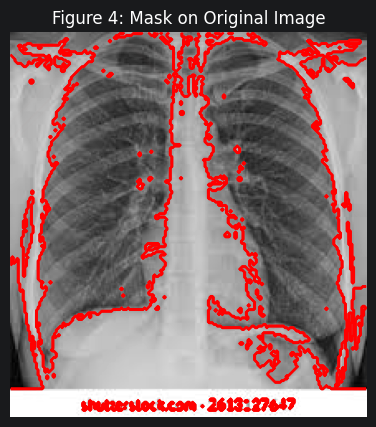

Threshold value used: 150
Foreground pixels: 22692
Total pixels: 50328
Selected area percentage: 45.09 %
Results saved as output_mask.png and output_edges.png


In [47]:
# Final Mini Project

image = cv2.imread("images/medical_image.jpeg", cv2.IMREAD_GRAYSCALE)

# image loaded or not check
if image is None:
    print("Error: Image not found. Check the file path.")
else:
    # --------------------------------
    # 2. Apply thresholding
    # --------------------------------
    threshold_value = 150
    _, mask = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)

    # --------------------------------
    # 3. Detect edges
    # --------------------------------
    edges = cv2.Canny(mask, 50, 150)

    # --------------------------------
    # 4. Save results
    # --------------------------------
    cv2.imwrite("images/output_mask.png", mask)
    cv2.imwrite("images/output_edges.png", edges)

    # --------------------------------
    # 5. Figure 1: Original Image
    # --------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(image, cmap="gray")
    plt.title("Figure 1: Original Image")
    plt.axis("off")
    plt.show()

    # --------------------------------
    # 6. Figure 2: Segmentation Mask
    # --------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(mask, cmap="gray")
    plt.title("Figure 2: Segmentation Mask")
    plt.axis("off")
    plt.show()

    # --------------------------------
    # 7. Figure 3: Edge Detection
    # --------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(edges, cmap="gray")
    plt.title("Figure 3: Edge Detection")
    plt.axis("off")
    plt.show()

    # --------------------------------
    # 8. Figure 4: Overlay
    # --------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(image, cmap="gray")
    plt.contour(mask, colors="red", linewidths=1)
    plt.title("Figure 4: Mask on Original Image")
    plt.axis("off")
    plt.show()

    # --------------------------------
    # 9. Print simple analysis
    # --------------------------------
    foreground_pixels = np.sum(mask == 255)
    total_pixels = mask.size
    percentage = 100 * foreground_pixels / total_pixels

    print("Threshold value used:", threshold_value)
    print("Foreground pixels:", foreground_pixels)
    print("Total pixels:", total_pixels)
    print("Selected area percentage:", round(percentage, 2), "%")
    print("Results saved as output_mask.png and output_edges.png")